In [428]:
import numpy as np
import pandas as pd
import seaborn as sns

import glob
import os
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

In [429]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import mean_squared_error, r2_score

In [430]:
font_path = 'C:\\Windows\\Fonts\\gulim.ttc'
font = fm.FontProperties(fname=font_path).get_name()
matplotlib.rc('font', family=font)
plt.rcParams['axes.unicode_minus'] = False

In [431]:
columns = ["short_name","age","nationality_name","mentality_penalties","attacking_finishing","power_shot_power","power_long_shots","movement_reactions", "gk", "fifa_update_date"]
player_list = []

file1 = "./../data/source data/players_stats.csv"
file2 = "./../data/source data/players_24.csv"
files = [file1, file2]
for file in files:
    stats_df = pd.read_csv(file, usecols=lambda x: x in columns)
    stats_df = stats_df[[col for col in columns if col in stats_df.columns]]
    if file == file1:
        stats_df["fifa_update_date"] = pd.to_datetime(stats_df["fifa_update_date"])
        stats_df["fifa_update_date"] = stats_df["fifa_update_date"].dt.year.astype(int)
    elif file == file2:
        stats_df["fifa_update_date"] = 2023
    player_list.append(stats_df)
    

merged_df = pd.concat(player_list, ignore_index=True)
merged_df.to_csv("./../data/result data/total_player_stats.csv")
merged_df.head()

C:\Users\user\AppData\Local\Temp\ipykernel_10572\1939526056.py:8: DtypeWarning: Columns (108) have mixed types. Specify dtype option on import or set low_memory=False.
  stats_df = pd.read_csv(file, usecols=lambda x: x in columns)


,short_name,age,nationality_name,mentality_penalties,attacking_finishing,power_shot_power,power_long_shots,movement_reactions,gk,fifa_update_date
0,L. Messi,27.0,Argentina,76.0,94.0,80.0,88.0,94.0,15+3,2014
1,Cristiano Ronaldo,29.0,Portugal,85.0,95.0,94.0,93.0,90.0,16+3,2014
2,A. Robben,30.0,Netherlands,80.0,85.0,86.0,90.0,89.0,14+3,2014
3,Z. Ibrahimović,32.0,Sweden,91.0,91.0,93.0,88.0,85.0,17+3,2014
4,M. Neuer,28.0,Germany,37.0,25.0,42.0,25.0,89.0,87+3,2014


In [432]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 161583 entries, 0 to 161582
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   short_name           161583 non-null  object 
 1   age                  161583 non-null  float64
 2   nationality_name     161583 non-null  object 
 3   mentality_penalties  161583 non-null  float64
 4   attacking_finishing  161583 non-null  float64
 5   power_shot_power     161583 non-null  float64
 6   power_long_shots     161583 non-null  float64
 7   movement_reactions   161583 non-null  float64
 8   gk                   161583 non-null  object 
 9   fifa_update_date     161583 non-null  int64  
dtypes: float64(6), int64(1), object(3)
memory usage: 12.3+ MB


In [433]:
merged_df.describe()

,age,mentality_penalties,attacking_finishing,power_shot_power,power_long_shots,movement_reactions,fifa_update_date
count,161583.000000,161583.000000,161583.000000,161583.000000,161583.000000,161583.000000,161583.000000
mean,25.123181,48.668492,45.617738,56.719098,47.152708,61.576824,2018.125514
std,4.670207,15.652208,19.227861,15.522391,19.010437,9.170063,2.559318
min,16.000000,5.000000,2.000000,2.000000,3.000000,20.000000,2014.000000
25%,21.000000,39.000000,30.000000,47.000000,32.000000,55.000000,2016.000000
50%,25.000000,50.000000,49.000000,59.000000,51.000000,62.000000,2018.000000
75%,28.000000,60.000000,61.000000,68.000000,62.000000,68.000000,2020.000000
max,54.000000,96.000000,95.000000,96.000000,94.000000,96.000000,2022.000000


In [434]:
# merged_df['movement_reactions'] = merged_df['movement_reactions'].dropna(axis=0)

In [435]:
columns = {
    'short_name':'Player_Name', 
    'age':'Age',
    'nationality_name':'Nation',
    'mentality_penalties':'Penalty', 
    'attacking_finishing':'Finishing', 
    'power_shot_power':'Shot_Power', 
    'power_long_shots':'Long_Shot', 
    'movement_reactions':'Reaction', 
    'fifa_update_date':'Year',
    'gk':'GK',
}

merged_df = merged_df.rename(columns=columns)
merged_df

,Player_Name,Age,Nation,Penalty,Finishing,Shot_Power,Long_Shot,Reaction,GK,Year
0,L. Messi,27.0,Argentina,76.0,94.0,80.0,88.0,94.0,15+3,2014
1,Cristiano Ronaldo,29.0,Portugal,85.0,95.0,94.0,93.0,90.0,16+3,2014
2,A. Robben,30.0,Netherlands,80.0,85.0,86.0,90.0,89.0,14+3,2014
3,Z. Ibrahimović,32.0,Sweden,91.0,91.0,93.0,88.0,85.0,17+3,2014
4,M. Neuer,28.0,Germany,37.0,25.0,42.0,25.0,89.0,87+3,2014
...,...,...,...,...,...,...,...,...,...,...
161578,Zhao Ziye,18.0,China PR,54.0,49.0,64.0,31.0,39.0,14+2,2022
161579,Wu Junjie,19.0,China PR,31.0,19.0,33.0,25.0,42.0,15+2,2022
161580,K. Barlow,19.0,Republic of Ireland,37.0,30.0,51.0,32.0,50.0,14+2,2022
161581,G. Tetteh,17.0,Republic of Ireland,63.0,56.0,42.0,47.0,45.0,15+2,2022


---

In [436]:
# 결측치 탐색
merged_df.isnull().sum()

Player_Name    0
Age            0
Nation         0
Penalty        0
Finishing      0
Shot_Power     0
Long_Shot      0
Reaction       0
GK             0
Year           0
dtype: int64

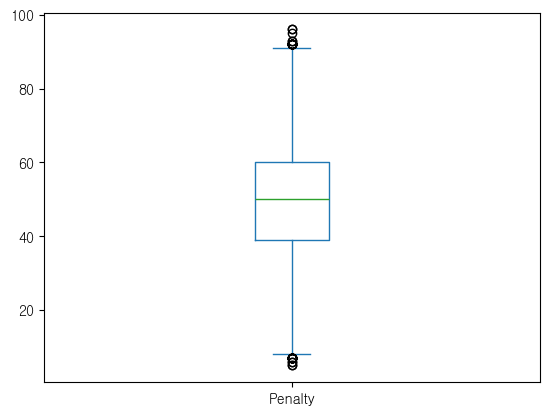

,Player_Name,Age,Nation,Penalty,Finishing,Shot_Power,Long_Shot,Reaction,GK,Year
684,R. Lambert,32.0,England,95.0,81.0,85.0,73.0,76.0,16,2014
17491,R. Lambert,33.0,England,96.0,81.0,85.0,74.0,75.0,20,2015
34506,R. Lambert,34.0,England,96.0,80.0,85.0,74.0,73.0,20+1,2016


In [437]:
# 이상치 탐색
merged_df['Penalty'].plot(kind='box')
plt.show()

merged_df[merged_df['Penalty'] < 0]
merged_df[merged_df['Penalty'] >= 95]

In [438]:
merged_df[merged_df['Player_Name'] == 'R. Lambert']

,Player_Name,Age,Nation,Penalty,Finishing,Shot_Power,Long_Shot,Reaction,GK,Year
684,R. Lambert,32.0,England,95.0,81.0,85.0,73.0,76.0,16,2014
17491,R. Lambert,33.0,England,96.0,81.0,85.0,74.0,75.0,20,2015
34506,R. Lambert,34.0,England,96.0,80.0,85.0,74.0,73.0,20+1,2016


---

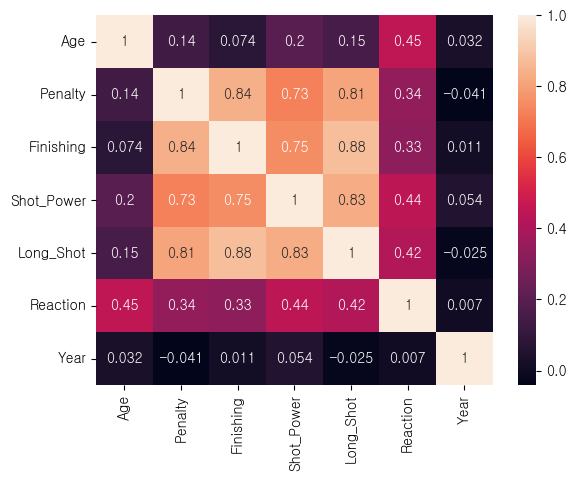

In [439]:
corr_matrix = merged_df.corr(numeric_only=True)

sns.heatmap(corr_matrix, annot=True)
plt.show()

---

In [440]:
# 전처리
merged_df['Age'] = merged_df['Age'].astype(int)
merged_df['Year'] = merged_df['Year'].astype(int)

In [441]:
# avg_df = merged_df.groupby("Player_Name").agg({
#     "Penalty": "mean",
#     "Age": "mean",
#     "Finishing": "mean",
#     "Shot_Power": "mean",
#     "Long_Shot": "mean",
#     "Reaction": "mean",
#     "GK": "first",
#     "Nation": "first"
# }).reset_index()
# avg_df

In [442]:
# top5_player = merged_df.groupby(["Year", "Nation"]).apply(
#     lambda x: x.nlargest(5, "Penalty")
# ).reset_index(drop=True)
# print(top5_player[top5_player['Nation'] == 'England'].sort_values("Penalty", ascending=False))

# team_success_prob = top5_player["Penalty"].mean()
# # print(team_success_prob["Penalty"].sort_values(ascending=False).head(10))

# fifa_stat_df = pd.DataFrame(top5_player)
# fifa_stat_df

In [443]:
df_match = pd.read_csv("./../data/source data/matches_1930_2022.csv")
df_match=df_match[['Year','home_team','away_team','Score']]
df_match

,Year,home_team,away_team,Score
0,2022,Argentina,France,(4) 3–3 (2)
1,2022,Croatia,Morocco,2–1
2,2022,France,Morocco,2–0
3,2022,Argentina,Croatia,3–0
4,2022,Morocco,Portugal,1–0
...,...,...,...,...
959,1930,Argentina,France,1–0
960,1930,Yugoslavia,Brazil,2–1
961,1930,Romania,Peru,3–1
962,1930,United States,Belgium,3–0


In [444]:
import re

"""
df_match['Score'] 예시: "(4) 3–3 (2)"
반환:  home_penalty_score=4, away_penalty_score=2
"""
def extract_penalty(score):
    pens = re.findall(r'\((\d+)\)', str(score))
    if len(pens) == 2:
        return int(pens[0]), int(pens[1])
    return None, None

df_match[['Home_Penalty_Score', 'Away_Penalty_Score']] = df_match['Score'].apply(
    lambda x: pd.Series(extract_penalty(x))
)
df_match = df_match.dropna(subset=['Home_Penalty_Score', 'Away_Penalty_Score'])
df_match

,Year,home_team,away_team,Score,Home_Penalty_Score,Away_Penalty_Score
0,2022,Argentina,France,(4) 3–3 (2),4.0,2.0
6,2022,Croatia,Brazil,(4) 1–1 (2),4.0,2.0
7,2022,Netherlands,Argentina,(3) 2–2 (4),3.0,4.0
8,2022,Morocco,Spain,(3) 0–0 (0),3.0,0.0
10,2022,Japan,Croatia,(1) 1–1 (3),1.0,3.0
69,2018,Russia,Croatia,(3) 2–2 (4),3.0,4.0
73,2018,Colombia,England,(3) 1–1 (4),3.0,4.0
76,2018,Spain,Russia,(3) 1–1 (4),3.0,4.0
77,2018,Croatia,Denmark,(3) 1–1 (2),3.0,2.0
130,2014,Netherlands,Argentina,(2) 0–0 (4),2.0,4.0


In [ ]:
df_match = df_match.drop(columns=['Score'])
df_match = df_match[df_match['Year'] >= 2014].reset_index(drop=True)
df_match

,Year,home_team,away_team,Home_Penalty_Score,Away_Penalty_Score
0,2022,Argentina,France,4.0,2.0
1,2022,Croatia,Brazil,4.0,2.0
2,2022,Netherlands,Argentina,3.0,4.0
3,2022,Morocco,Spain,3.0,0.0
4,2022,Japan,Croatia,1.0,3.0
5,2018,Russia,Croatia,3.0,4.0
6,2018,Colombia,England,3.0,4.0
7,2018,Spain,Russia,3.0,4.0
8,2018,Croatia,Denmark,3.0,2.0
9,2014,Netherlands,Argentina,2.0,4.0


In [447]:
country_map = {  
    "Iran":"IR Iran"
}

merged_df['Nation'] = merged_df['Nation'].map(country_map)
df_team_renamed = merged_df.set_index(['Year', 'Nation'])

missing_teams = set()

def penalty_result():
    home_pen = df_match['Home_Penalty_Score']
    away_pen = df_match['Away_Penalty_Score']
    if home_pen > away_pen:
        return 1
    elif home_pen < away_pen:
        return -1
    
def map_team_features_safe(row):
    year = row['Year']
    home = row['home_team']
    away = row['away_team']
    
    # 홈팀 특징
    try:
        home_feat = df_team_renamed.loc[(year, home)].add_prefix("Home_")
    except KeyError:
        missing_teams.add(home)
        home_feat = pd.Series(dtype=float)
    
    # 어웨이팀 특징
    try:
        away_feat = df_team_renamed.loc[(year, away)].add_prefix("Away_")
    except KeyError:
        missing_teams.add(away)
        away_feat = pd.Series(dtype=float)
    
    return pd.concat([home_feat, away_feat, pd.Series({'Penalty_Result': penalty_result()})])

In [450]:
df_final = df_match.apply(map_team_features_safe, axis=1).reset_index(drop=True)

if missing_teams:
    print("매핑이 안 된 팀:", missing_teams)

print(df_final.head())

C:\Users\user\AppData\Local\Temp\ipykernel_10572\279541201.py:25: PerformanceWarning: indexing past lexsort depth may impact performance.
  home_feat = df_team_renamed.loc[(year, home)].add_prefix("Home_")
C:\Users\user\AppData\Local\Temp\ipykernel_10572\279541201.py:32: PerformanceWarning: indexing past lexsort depth may impact performance.
  away_feat = df_team_renamed.loc[(year, away)].add_prefix("Away_")


ValueError: The truth value of a Series is ambiguous. Use a.empty, a.bool(), a.item(), a.any() or a.all().

---

In [ ]:
# merged_df.set_index("Player_Name", inplace=True)

# 피처-라벨 분리
X = merged_df.drop(columns=["Penalty", "Player_Name", "Nation", "GK"]) # Age	Finishing	Shot_Power	Long_Shot	Reaction    Year
y = merged_df["Penalty"]

# 훈련-평가 분리
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# scaler = StandardScaler()
# X_train_scaled = scaler.fit_transform(X_train)
# X_test_scaled = scaler.transform(X_test)

# 모델 학습 및 평가
xgb = XGBRegressor(n_estimators=300, learning_rate=0.2, max_depth=5, random_state=42)
xgb.fit(X_train, y_train)
print(xgb.score(X_train, y_train)), print(xgb.score(X_test, y_test))

y_pred = xgb.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"MSE : {mse}, RMSE: {rmse}, R2: {r2}")

0.7989975966342739
0.7808955866085145
MSE : 53.378581752773336, RMSE: 7.306064724102391, R2: 0.7808955866085145


- 나이에 가중치?
- top5선수 평균 말고 시뮬레이션?
- get_score(fmap='', importance_type='weight') 

In [ ]:
merged_df["Penalty_Prob"] = np.clip(xgb.predict(X) / 100.0, 0, 1)

# top5_player = merged_df.groupby("Nation").apply(
#     lambda x: x.nlargest(5, "Penalty_Prob")
# ).reset_index(drop=True)
# print(top5_player[top5_player['Nation'] == 'England'].sort_values("Penalty_Prob", ascending=False))
# 
# team_success_prob = top5_player.groupby("Nation")["Penalty_Prob"].mean()
# print(team_success_prob.sort_values(ascending=False).head(10))